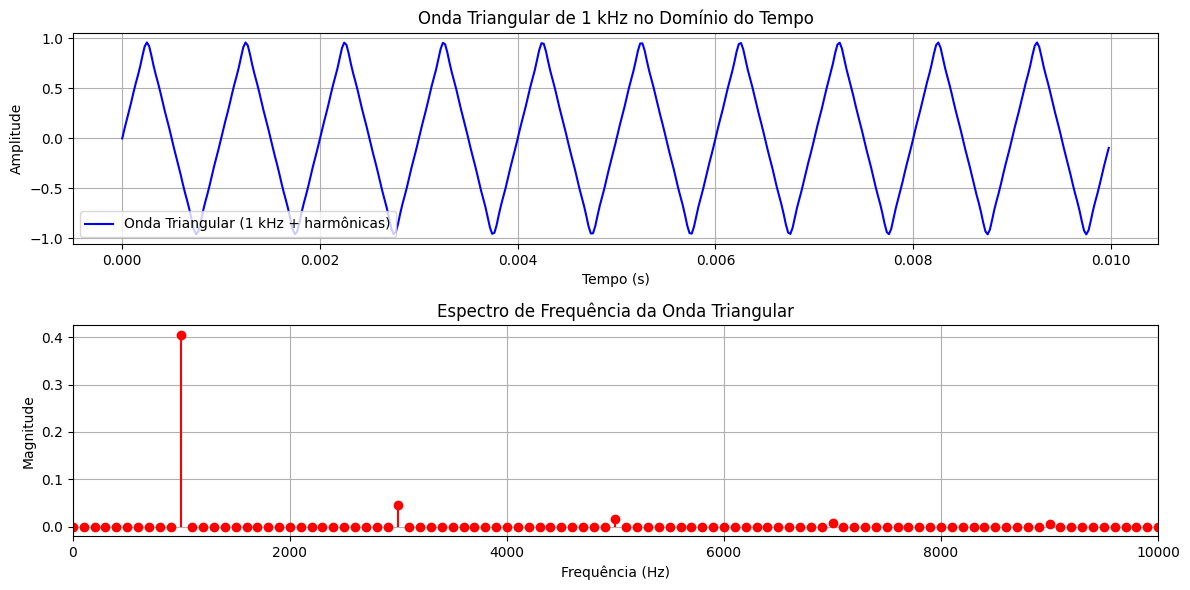

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parâmetros do sinal
frequencia_fundamental = 1000  # 1 kHz
amplitude = 1.0
tempo_amostragem = 1.0 / 44100  # Taxa de amostragem de 44.1 kHz
duracao = 0.01  # 10 ms
t = np.arange(0, duracao, tempo_amostragem)

# Gerar onda triangular usando a Série de Fourier (apenas harmônicas ímpares)
def onda_triangular(t, freq, amplitude, num_harmonicas=10):
    sinal = np.zeros_like(t)
    for n in range(1, num_harmonicas + 1, 2):  # Apenas harmônicas ímpares (1, 3, 5, ...)
        sinal += ((-1)**((n-1)//2)) * (amplitude / (n**2)) * np.sin(2 * np.pi * n * freq * t)
    sinal *= (8 / (np.pi**2))  # Fator de normalização
    return sinal

# Gerar a onda triangular e suas componentes
triangular = onda_triangular(t, frequencia_fundamental, amplitude, num_harmonicas=9)

# Plotar o sinal no tempo
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, triangular, 'b', label='Onda Triangular (1 kHz + harmônicas)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.title('Onda Triangular de 1 kHz no Domínio do Tempo')
plt.grid(True)
plt.legend()

# Plotar o espectro de frequência
plt.subplot(2, 1, 2)
frequencias = np.fft.fftfreq(len(t), tempo_amostragem)
fft_triangular = np.fft.fft(triangular)
fft_magnitude = np.abs(fft_triangular) / len(t)  # Normalização

plt.stem(frequencias[:len(frequencias)//2], fft_magnitude[:len(frequencias)//2], 'r', markerfmt='ro', basefmt=" ")
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.title('Espectro de Frequência da Onda Triangular')
plt.xlim(0, 10000)  # Mostrar até 10 kHz
plt.grid(True)

plt.tight_layout()
plt.show()

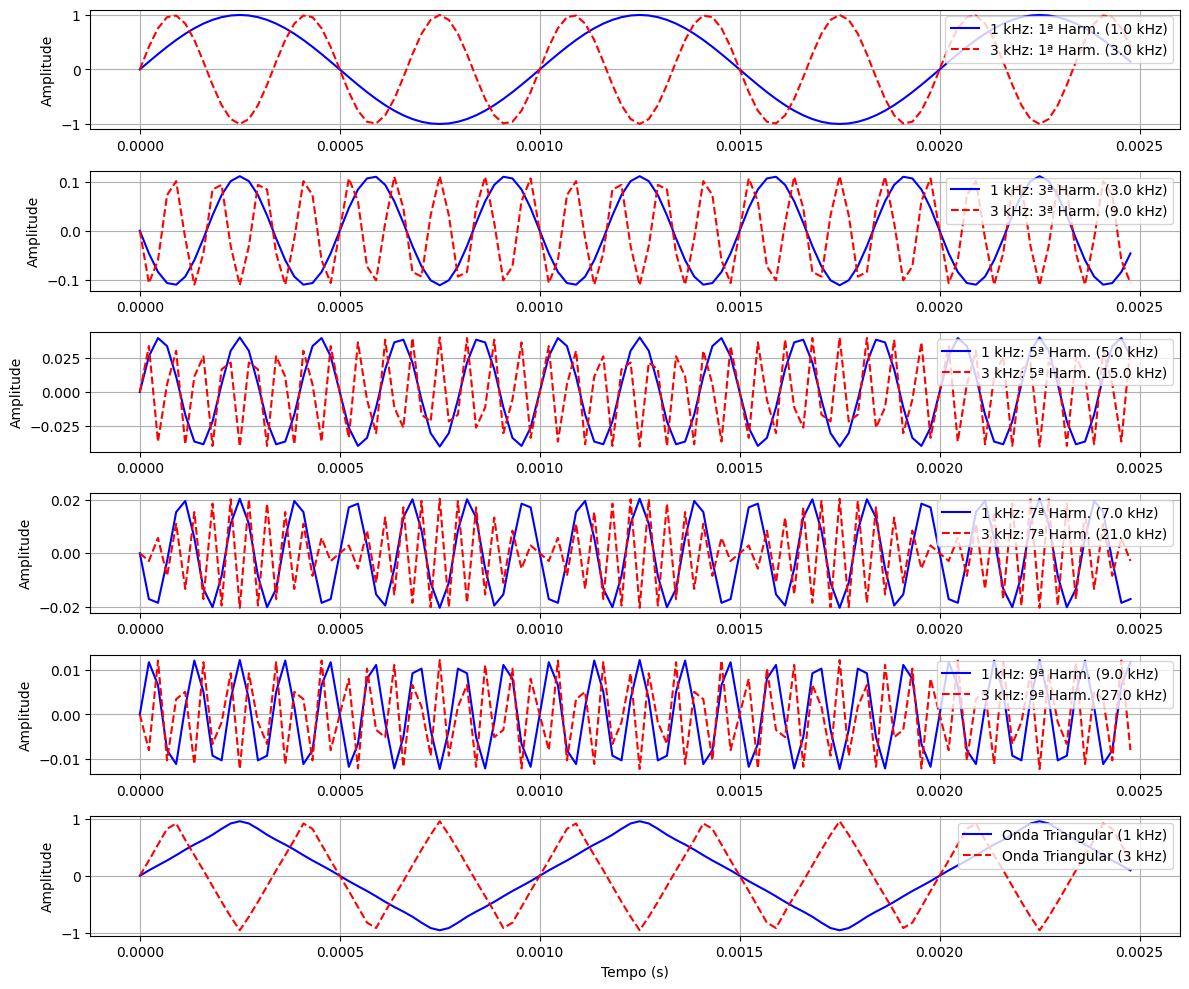

In [8]:
# Configurações
freq_1k = 1000  # 1 kHz
freq_3k = 3000  # 2 kHz
amplitude = 1.0
taxa_amostragem = 44100  # 44.1 kHz
duracao = 0.0025  # 5 ms (para melhor visualização)
t = np.linspace(0, duracao, int(taxa_amostragem * duracao), endpoint=False)

# Função para gerar componentes
def componentes_triangulares(t, freq, amplitude, num_harmonicas=5):
    componentes = []
    for n in range(1, 2 * num_harmonicas, 2):  # Ímpares: 1, 3, 5, ...
        componente = ((-1)**((n-1)//2)) * (amplitude / (n**2)) * np.sin(2 * np.pi * n * freq * t)
        componentes.append(componente)
    return componentes

# Gerar componentes para 1 kHz e 2 kHz
num_harmonicas = 5
comp_1k = componentes_triangulares(t, freq_1k, amplitude, num_harmonicas)
comp_3k = componentes_triangulares(t, freq_3k, amplitude, num_harmonicas)

# Somas finais (ondas triangulares)
triangular_1k = np.sum(comp_1k, axis=0) * (8 / (np.pi**2))
triangular_3k = np.sum(comp_3k, axis=0) * (8 / (np.pi**2))

# Plotar
plt.figure(figsize=(12, 10))
cores = ['b', 'r']  # 1 kHz em azul, 2 kHz em vermelho

# Plotar cada harmônica (1 kHz vs 2 kHz)
for i in range(num_harmonicas):
    plt.subplot(num_harmonicas + 1, 1, i + 1)
    freq_harm_1k = (2*i + 1) * freq_1k
    freq_harm_3k = (2*i + 1) * freq_3k
    
    plt.plot(t, comp_1k[i], 'b', label=f'1 kHz: {2*i+1}ª Harm. ({freq_harm_1k/1000:.1f} kHz)')
    plt.plot(t, comp_3k[i], 'r--', label=f'3 kHz: {2*i+1}ª Harm. ({freq_harm_3k/1000:.1f} kHz)')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True)

# Plotar a soma final
plt.subplot(num_harmonicas + 1, 1, num_harmonicas + 1)
plt.plot(t, triangular_1k, 'b', label='Onda Triangular (1 kHz)')
plt.plot(t, triangular_3k, 'r--', label='Onda Triangular (3 kHz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()